In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Excel file if df has not already been defined
file_path = r"C:\Users\aman4645\OneDrive\Documents\New folder\cleaned_customer_shopping_data.xlsx"

if "df" not in globals():
	df = pd.read_excel(file_path)

# Save the dataframe
df.to_excel(file_path, index=False)

# Display first few rows to confirm it loaded correctly
df.head()
# Inspect structure
df.info()
print(df.isna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  str           
 1   customer_id     99457 non-null  str           
 2   gender          99457 non-null  str           
 3   age             99457 non-null  int64         
 4   category        99457 non-null  str           
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  str           
 8   invoice_date    99457 non-null  datetime64[us]
 9   shopping_mall   99457 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(6)
memory usage: 7.6 MB
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
d

# I Using My Previous Clean Data(Level 1-(EDA on Retail Sales Data) or Task 1) in This Task.

In [11]:
# Calculate total sales for each transaction
df['total_sales'] = df['quantity'] * df['price']

# Average purchase value (per transaction)
avg_purchase_value = df['total_sales'].mean()

# Purchase frequency (avg number of purchases per customer)
purchase_frequency = df.groupby('customer_id')['invoice_no'].count().mean()

# Customer Lifetime Value (avg total spend per customer)
clv = df.groupby('customer_id')['total_sales'].sum().mean()

print("Average Purchase Value:", round(avg_purchase_value, 2))
print("Average Purchase Frequency per Customer:", round(purchase_frequency, 2))
print("Average Customer Lifetime Value:", round(clv, 2))

Average Purchase Value: 2528.79
Average Purchase Frequency per Customer: 1.0
Average Customer Lifetime Value: 2528.79


# Descriptive statistics Analysis
Average Purchase Value: 2528.79

Average Purchase Frequency per Customer: 1.0

Average Customer Lifetime Value: 2528.79


In [12]:
snapshot_date = df['invoice_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('invoice_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('invoice_no', 'count'),
    Monetary=('total_sales', 'sum')
).reset_index()

print(rfm.head())
print(rfm.shape)
rfm.describe()


  customer_id  Recency  Frequency  Monetary
0     C100004      468          1   7502.00
1     C100005        6          1   2400.68
2     C100006       98          1    322.56
3     C100012      571          1    130.75
4     C100019      592          1     35.84
(99457, 4)


,Recency,Frequency,Monetary
count,99457.000000,99457.0,99457.000000
mean,397.884030,1.0,2528.789268
std,229.871351,0.0,4222.475781
min,1.000000,1.0,5.230000
25%,199.000000,1.0,136.350000
50%,397.000000,1.0,600.170000
75%,598.000000,1.0,2700.720000
max,797.000000,1.0,26250.000000


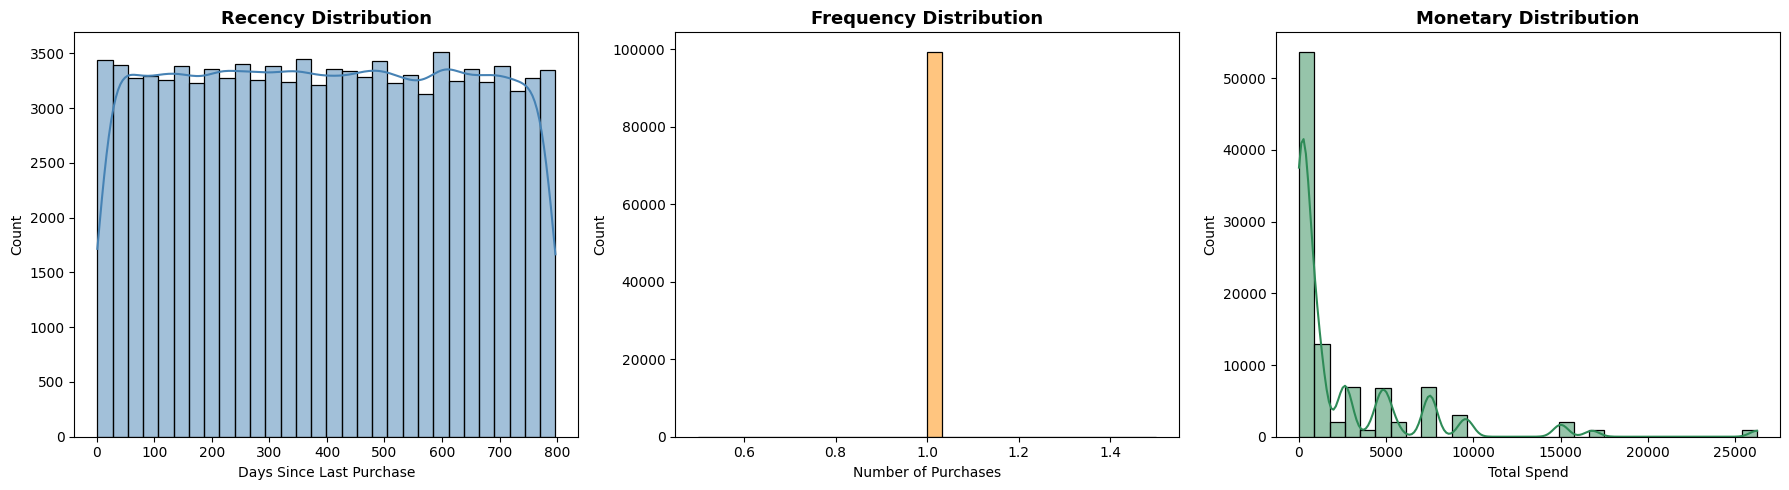

In [30]:
# RFM Analysis

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(rfm['Recency'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Recency Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')

sns.histplot(rfm['Frequency'], bins=30, kde=True, color='darkorange', ax=axes[1])
axes[1].set_title('Frequency Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Purchases')

sns.histplot(rfm['Monetary'], bins=30, kde=True, color='seagreen', ax=axes[2])
axes[2].set_title('Monetary Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Total Spend')

plt.tight_layout()
plt.show()

### RFM Distribution Analysis

**Recency:** Fairly evenly spread between 0-800 days, with no strong concentration — customers' last purchase 
dates are spread across the full time range, suggesting no major recent drop-off in overall activity.

**Frequency:** Nearly all customers show a Frequency of 1 — meaning almost every customer in this dataset made 
only a single purchase. This suggests the dataset represents mostly one-time buyers rather than repeat customers, 
which will affect segmentation since Frequency won't meaningfully separate customers into distinct groups.

**Monetary:** Heavily right-skewed — most customers spend a relatively small amount, while a smaller group of 
high-value customers spend significantly more (up to ~25,000+). This is the most useful feature for identifying 
high-value vs low-value customer segments.

**Implication for clustering:** Since Frequency has almost no variation, Recency and Monetary will likely drive 
the clustering results more than Frequency.

In [14]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Convert back to a DataFrame for easier viewing
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,0.305024,0.0,1.177801
1,-1.704806,0.0,-0.030340
2,-1.304580,0.0,-0.522499
3,0.753103,0.0,-0.567925
4,0.844459,0.0,-0.590403


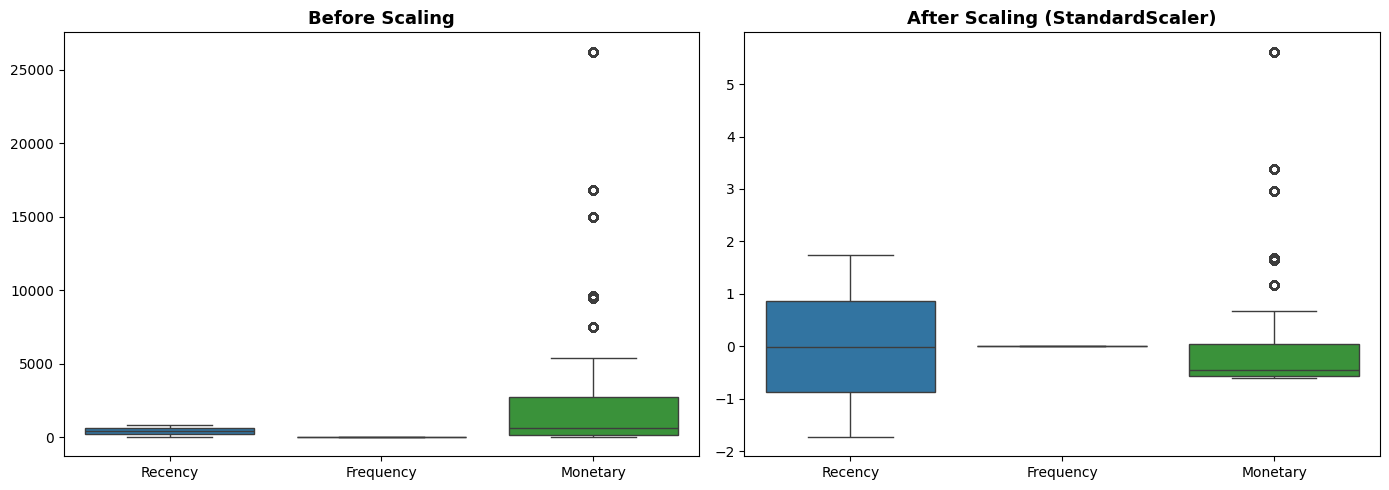

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=rfm[['Recency','Frequency','Monetary']], ax=axes[0])
axes[0].set_title('Before Scaling', fontsize=13, fontweight='bold')

sns.boxplot(data=rfm_scaled_df, ax=axes[1])
axes[1].set_title('After Scaling (StandardScaler)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Preparing Data for Clustering

Recency, Frequency, and Monetary are on very different scales (days vs. spend in thousands). Before clustering, 
we standardized them using `StandardScaler` so no single feature dominates just because its numbers are bigger.

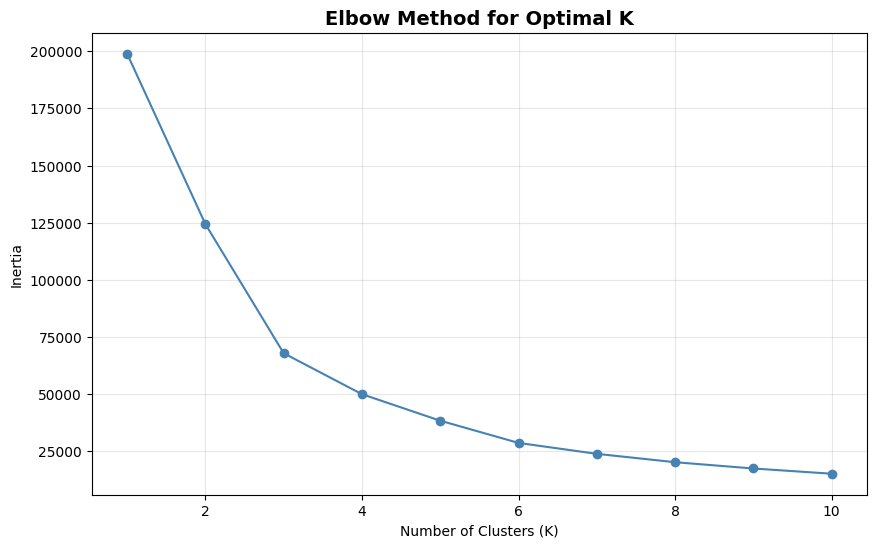

In [16]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10,6))
plt.plot(K_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.show()

## Finding the Right Number of Customer Groups

We tested splitting customers into different numbers of groups (1 to 10) and measured how well each split worked. 

The line drops sharply until **K = 4**, then flattens out — meaning splitting customers into more than 4 groups 
gives little extra benefit. 

**Decision: We'll use K = 4** — enough to capture meaningful differences between customers, without over-splitting 
them into groups that are too similar to matter.

In [20]:
# Standardize RFM features before clustering
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

from sklearn.cluster import KMeans

#  Apply K-Means clustering with K=4 to assign each customer to a segment.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,customer_id,Recency,Frequency,Monetary,Cluster
0,C100004,468,1,7502.00,3
1,C100005,6,1,2400.68,0
2,C100006,98,1,322.56,0
3,C100012,571,1,130.75,2
4,C100019,592,1,35.84,2


## Grouping Customers into Segments

Using K = 4 (from the Elbow Method), we applied K-Means clustering to sort customers into 4 distinct groups 
based on their Recency, Frequency, and Monetary values.

## Visualizing the Customer Segments

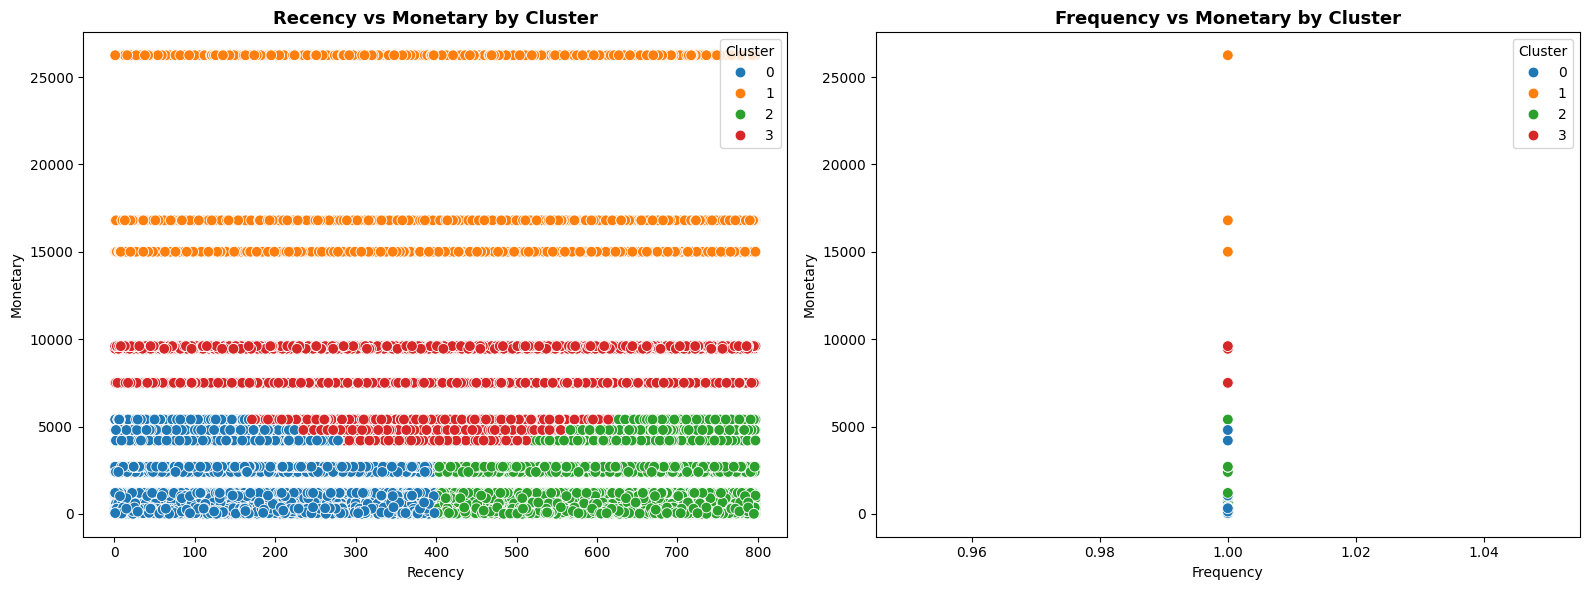

In [22]:
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Recency vs Monetary
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='tab10', s=60, ax=axes[0])
axes[0].set_title('Recency vs Monetary by Cluster', fontsize=13, fontweight='bold')

# Frequency vs Monetary
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='tab10', s=60, ax=axes[1])
axes[1].set_title('Frequency vs Monetary by Cluster', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## What the Clusters Look Like

Looking at the scatter plots, a clear pattern emerges — customers split mainly by **how much they spend**:

- 🟠 **Cluster 1 (Orange):** Big spenders — spend far more (15,000+) than everyone else, regardless of when 
  they shopped.
- 🔴 **Cluster 3 (Red):** Mid-to-high spenders — spend a solid 7,500-10,000.
- 🟢🔵 **Clusters 0 & 2 (Blue/Green):** Lower spenders — spend under 5,500, and mostly split by *when* they 
  last shopped (recent vs. older customers).

The right chart confirms Frequency isn't the deciding factor — nearly all customers bought only once, so 
**spending amount and recency**, not repeat visits, are what separate these groups.

## Profiling Each Segment

In [24]:
cluster_profile = rfm.groupby('Cluster').agg(
    Recency_mean=('Recency', 'mean'),
    Frequency_mean=('Frequency', 'mean'),
    Monetary_mean=('Monetary', 'mean'),
    Customer_Count=('customer_id', 'count')
).round(2).reset_index()

print(cluster_profile)

   Cluster  Recency_mean  Frequency_mean  Monetary_mean  Customer_Count
0        0        193.61             1.0         918.13           40618
1        1        393.79             1.0       18255.69            4015
2        2        603.60             1.0         953.38           40531
3        3        396.20             1.0        7155.59           14293


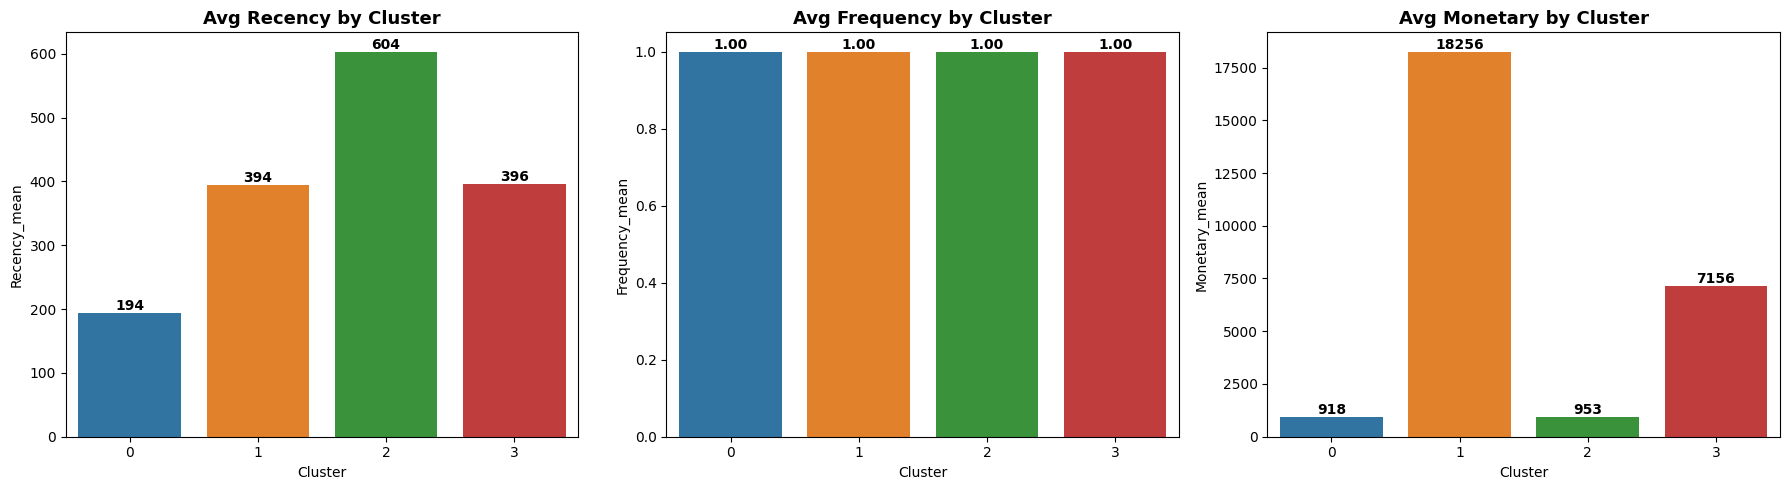

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.barplot(data=cluster_profile, x='Cluster', y='Recency_mean', hue='Cluster', palette='tab10', legend=False, ax=axes[0])
axes[0].set_title('Avg Recency by Cluster', fontsize=13, fontweight='bold')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', fontweight='bold')

sns.barplot(data=cluster_profile, x='Cluster', y='Frequency_mean', hue='Cluster', palette='tab10', legend=False, ax=axes[1])
axes[1].set_title('Avg Frequency by Cluster', fontsize=13, fontweight='bold')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', fontweight='bold')

sns.barplot(data=cluster_profile, x='Cluster', y='Monetary_mean', hue='Cluster', palette='tab10', legend=False, ax=axes[2])
axes[2].set_title('Avg Monetary by Cluster', fontsize=13, fontweight='bold')
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.0f', fontweight='bold')

plt.tight_layout()
plt.show()

## Meet the 4 Customer Segments

- 🔵 **Cluster 0 — Recent, Low Spenders:** Shopped recently (194 days ago on avg) but spend the least (918).
- 🟠 **Cluster 1 — Big Spenders:** Highest spenders by far (18,256 avg), shopped fairly recently (394 days).
- 🟢 **Cluster 2 — Inactive, Low Spenders:** Haven't shopped in a long time (604 days) and spend the least (953).
- 🔴 **Cluster 3 — Mid Spenders:** Spend a solid 7,156, shopped moderately recently (396 days).

**Takeaway:** Spending amount is what separates these groups the most, with recency adding a second layer — 
some low spenders are still active, others have drifted away.

## How Many Customers Are in Each Segment

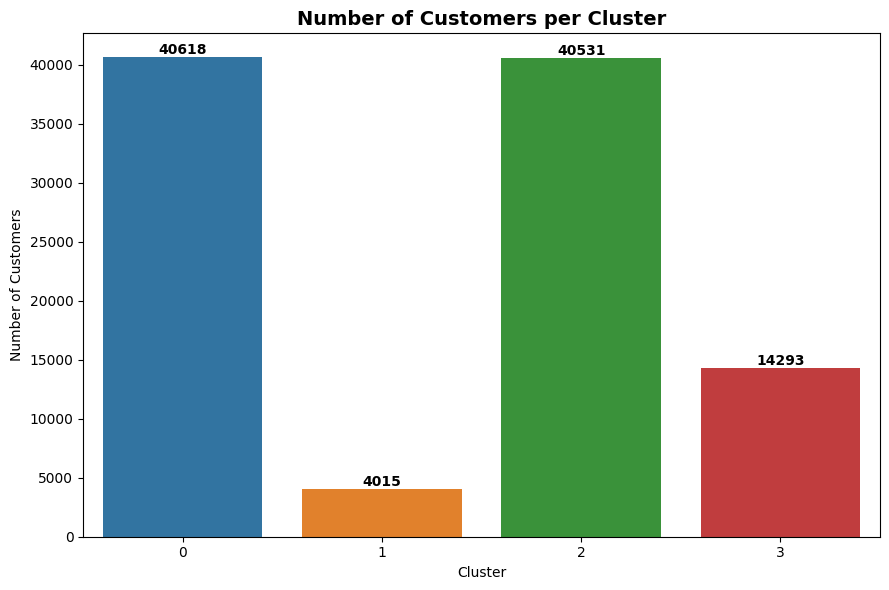

In [31]:
plt.figure(figsize=(9,6))
ax = sns.barplot(data=cluster_profile, x='Cluster', y='Customer_Count', hue='Cluster', palette='tab10', legend=False)

for container in ax.containers:
    ax.bar_label(container, fontweight='bold')

plt.title('Number of Customers per Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

## Segment Sizes

- 🔵 **Cluster 0 (Recent, Low Spenders):** 40,618 customers — our largest group.
- 🟢 **Cluster 2 (Inactive, Low Spenders):** 40,531 customers — almost equally large.
- 🔴 **Cluster 3 (Mid Spenders):** 14,293 customers — a solid mid-sized group.
- 🟠 **Cluster 1 (Big Spenders):** Just 4,015 customers — small, but the most valuable.

**Takeaway:** Most customers spend little, while our highest-value segment is also our smallest — a classic 
80/20 pattern where a small group likely drives a disproportionate share of revenue.

# Insights section: 
what marketing action would I recommend for each segment.

## Marketing Recommendations by Segment

- 🔵 **Cluster 0 — Recent, Low Spenders (40,618 customers):** Recently active but spending little. 
  **Action:** Upsell/cross-sell offers to increase basket size while they're already engaged.

- 🟠 **Cluster 1 — Big Spenders (4,015 customers):** Small group, highest value. 
  **Action:** VIP treatment — loyalty rewards, early access, personalized offers to retain them.

- 🟢 **Cluster 2 — Inactive, Low Spenders (40,531 customers):** Haven't shopped in a long time, low spend. 
  **Action:** Win-back campaigns (discount codes, "we miss you" emails) to re-engage before they're fully lost.

- 🔴 **Cluster 3 — Mid Spenders (14,293 customers):** Moderate spend and recency. 
  **Action:** Nurture toward Cluster 1 with targeted promotions on higher-value products.